# <span style="color:#00bfff">Análisis Exploratorio de Datos (Exploratory Data Analysis - EDA) en Python usando ``pandas``</span>

Modificado de: <i>[Data Professor YouTube channel](http://youtube.com/dataprofessor), http://youtube.com/dataprofessor </i>

## <span style="color:#00bfff">Web scraping data</span>

The following block of code will retrieve the "2018-19 NBA Player Stats: Per Game" data from http://www.basketball-reference.com/.

> **Note:** basketball-reference.com sometimes returns a 403 Forbidden error for requests without browser-like headers, so the request below sends a `User-Agent` header to reduce that risk. If scraping still fails for you (network restrictions, rate limiting, etc.), the already-scraped `nba2019.csv` file included in this folder can be used instead (see the `pd.read_csv('nba2019.csv')` cell further below).

In [ ]:
import pandas as pd
import requests
from io import StringIO

# Retrieve HTML table data
url = 'https://www.basketball-reference.com/leagues/NBA_2019_per_game.html'
headers = {'User-Agent': 'Mozilla/5.0'}  # evita algunos bloqueos 403 del sitio

try:
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()
    html = pd.read_html(StringIO(response.text), header=0)
    df2019 = html[0]
except Exception as e:
    print(f"No se pudo obtener los datos en vivo ({e}); usando el respaldo local 'nba2019.csv'.")
    df2019 = pd.read_csv('nba2019.csv')

# Data cleaning
raw = df2019.drop(df2019[df2019.Age == 'Age'].index) if 'Age' in df2019.columns else df2019
raw

<span style="color:#00bfff">**Acrónimos de los datos**</span>

<span style="color:#00bfff">__Acrónimo__</span> | <span style="color:#00bfff">__Descripción__</span>
---|---
Rk | Rank
Pos | Position
Age | Player's age on February 1 of the season
Team | Team
G | Games
GS | Games Started
MP | Minutes Played Per Game
FG | Field Goals Per Game
FGA | Field Goal Attempts Per Game
FG% | Field Goal Percentage
3P | 3-Point Field Goals Per Game
3PA | 3-Point Field Goal Attempts Per Game
3P% | FG% on 3-Pt FGAs.
2P | 2-Point Field Goals Per Game
2PA | 2-Point Field Goal Attempts Per Game
2P% | FG% on 2-Pt FGAs.
eFG% | Effective Field Goal Percentage
|| *(Note: This statistic adjusts for the fact that a 3-point field goal is worth one more point than a 2-point field goal.)*
FT | Free Throws Per Game
FTA | Free Throw Attempts Per Game
FT% | Free Throw Percentage
ORB | Offensive Rebounds Per Game
DRB | Defensive Rebounds Per Game
TRB | Total Rebounds Per Game
AST | Assists Per Game
STL | Steals Per Game
BLK | Blocks Per Game
TOV | Turnovers Per Game
PF | Personal Fouls Per Game
PTS | Points Per Game

## <span style="color:#00bfff">Data cleaning</span>

<span style="color:#00bfff;">1.</span> Data dimension

In [4]:
raw.shape

(709, 31)

<span style="color:#00bfff;">2.</span> Dataframe contents

In [5]:
raw.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,1.0,James Harden,29.0,HOU,PG,78.0,78.0,36.8,10.8,24.5,...,0.8,5.8,6.6,7.5,2.0,0.7,5.0,3.1,36.1,"MVP-2,AS,NBA1"
1,2.0,Paul George,28.0,OKC,SF,77.0,77.0,36.9,9.2,21.0,...,1.4,6.8,8.2,4.1,2.2,0.4,2.7,2.8,28.0,"MVP-3,DPOY-3,AS,NBA1,DEF1"
2,3.0,Giannis Antetokounmpo,24.0,MIL,PF,72.0,72.0,32.8,10.0,17.3,...,2.2,10.3,12.5,5.9,1.3,1.5,3.7,3.2,27.7,"MVP-1,DPOY-2,AS,NBA1,DEF1"
3,4.0,Joel Embiid,24.0,PHI,C,64.0,64.0,33.7,9.1,18.7,...,2.5,11.1,13.6,3.7,0.7,1.9,3.5,3.3,27.5,"MVP-7,DPOY-4,AS,NBA2,DEF2"
4,5.0,LeBron James,34.0,LAL,SF,55.0,55.0,35.2,10.1,19.9,...,1.0,7.4,8.5,8.3,1.3,0.6,3.6,1.7,27.4,"MVP-11,AS,NBA3"


<span style="color:#00bfff;">3.</span> Check for missing values

In [6]:
raw.isnull().sum()

Rk          1
Player      0
Age         1
Team        1
Pos         1
G           1
GS          1
MP          1
FG          1
FGA         1
FG%         6
3P          1
3PA         1
3P%        47
2P          1
2PA         1
2P%        15
eFG%        6
FT          1
FTA         1
FT%        43
ORB         1
DRB         1
TRB         1
AST         1
STL         1
BLK         1
TOV         1
PF          1
PTS         1
Awards    651
dtype: int64

<span style="color:#00bfff;">4.</span> Replace missing values with 0 

In [7]:
df = raw.fillna(0)

In [8]:
df.isnull().sum()

Rk        0
Player    0
Age       0
Team      0
Pos       0
G         0
GS        0
MP        0
FG        0
FGA       0
FG%       0
3P        0
3PA       0
3P%       0
2P        0
2PA       0
2P%       0
eFG%      0
FT        0
FTA       0
FT%       0
ORB       0
DRB       0
TRB       0
AST       0
STL       0
BLK       0
TOV       0
PF        0
PTS       0
Awards    0
dtype: int64

In [9]:
df = df.drop(['Rk'], axis=1)
df

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,James Harden,29.0,HOU,PG,78.0,78.0,36.8,10.8,24.5,0.442,...,0.8,5.8,6.6,7.5,2.0,0.7,5.0,3.1,36.1,"MVP-2,AS,NBA1"
1,Paul George,28.0,OKC,SF,77.0,77.0,36.9,9.2,21.0,0.438,...,1.4,6.8,8.2,4.1,2.2,0.4,2.7,2.8,28.0,"MVP-3,DPOY-3,AS,NBA1,DEF1"
2,Giannis Antetokounmpo,24.0,MIL,PF,72.0,72.0,32.8,10.0,17.3,0.578,...,2.2,10.3,12.5,5.9,1.3,1.5,3.7,3.2,27.7,"MVP-1,DPOY-2,AS,NBA1,DEF1"
3,Joel Embiid,24.0,PHI,C,64.0,64.0,33.7,9.1,18.7,0.484,...,2.5,11.1,13.6,3.7,0.7,1.9,3.5,3.3,27.5,"MVP-7,DPOY-4,AS,NBA2,DEF2"
4,LeBron James,34.0,LAL,SF,55.0,55.0,35.2,10.1,19.9,0.510,...,1.0,7.4,8.5,8.3,1.3,0.6,3.6,1.7,27.4,"MVP-11,AS,NBA3"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
704,Zach Lofton,26.0,DET,SG,1.0,0.0,4.0,0.0,1.0,0.000,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0
705,Kobi Simmons,21.0,CLE,PG,1.0,0.0,2.0,0.0,0.0,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
706,Tyler Ulis,23.0,CHI,PG,1.0,0.0,1.0,0.0,0.0,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
707,Okaro White,26.0,WAS,PF,3.0,0.0,2.0,0.0,0.7,0.000,...,0.3,0.3,0.7,0.0,0.0,0.0,0.0,0.0,0.0,0


## <span style="color:#00bfff;"> Write to CSV file</span>

In [10]:
df.to_csv('nba2019.csv', index=False)

In [ ]:
# %ls es un "magic command" de IPython: funciona igual en Windows, macOS y Linux dentro de Jupyter.
# !ls, en cambio, depende de la terminal del sistema operativo.
%ls

## <span style="color:#00bfff;">Exploratory Data Analysis</span>

<span style="color:#00bfff;">1.</span> Read data

In [12]:
df = pd.read_csv('nba2019.csv')

<span style="color:#00bfff;">2.</span> Displays the dataframe

In [13]:
df

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,James Harden,29.0,HOU,PG,78.0,78.0,36.8,10.8,24.5,0.442,...,0.8,5.8,6.6,7.5,2.0,0.7,5.0,3.1,36.1,"MVP-2,AS,NBA1"
1,Paul George,28.0,OKC,SF,77.0,77.0,36.9,9.2,21.0,0.438,...,1.4,6.8,8.2,4.1,2.2,0.4,2.7,2.8,28.0,"MVP-3,DPOY-3,AS,NBA1,DEF1"
2,Giannis Antetokounmpo,24.0,MIL,PF,72.0,72.0,32.8,10.0,17.3,0.578,...,2.2,10.3,12.5,5.9,1.3,1.5,3.7,3.2,27.7,"MVP-1,DPOY-2,AS,NBA1,DEF1"
3,Joel Embiid,24.0,PHI,C,64.0,64.0,33.7,9.1,18.7,0.484,...,2.5,11.1,13.6,3.7,0.7,1.9,3.5,3.3,27.5,"MVP-7,DPOY-4,AS,NBA2,DEF2"
4,LeBron James,34.0,LAL,SF,55.0,55.0,35.2,10.1,19.9,0.510,...,1.0,7.4,8.5,8.3,1.3,0.6,3.6,1.7,27.4,"MVP-11,AS,NBA3"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
704,Zach Lofton,26.0,DET,SG,1.0,0.0,4.0,0.0,1.0,0.000,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0
705,Kobi Simmons,21.0,CLE,PG,1.0,0.0,2.0,0.0,0.0,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
706,Tyler Ulis,23.0,CHI,PG,1.0,0.0,1.0,0.0,0.0,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
707,Okaro White,26.0,WAS,PF,3.0,0.0,2.0,0.0,0.7,0.000,...,0.3,0.3,0.7,0.0,0.0,0.0,0.0,0.0,0.0,0


If we want to see more...

In [14]:
pd.set_option('display.max_rows', df.shape[0]+1)
df

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,James Harden,29.0,HOU,PG,78.0,78.0,36.8,10.8,24.5,0.442,...,0.8,5.8,6.6,7.5,2.0,0.7,5.0,3.1,36.1,"MVP-2,AS,NBA1"
1,Paul George,28.0,OKC,SF,77.0,77.0,36.9,9.2,21.0,0.438,...,1.4,6.8,8.2,4.1,2.2,0.4,2.7,2.8,28.0,"MVP-3,DPOY-3,AS,NBA1,DEF1"
2,Giannis Antetokounmpo,24.0,MIL,PF,72.0,72.0,32.8,10.0,17.3,0.578,...,2.2,10.3,12.5,5.9,1.3,1.5,3.7,3.2,27.7,"MVP-1,DPOY-2,AS,NBA1,DEF1"
3,Joel Embiid,24.0,PHI,C,64.0,64.0,33.7,9.1,18.7,0.484,...,2.5,11.1,13.6,3.7,0.7,1.9,3.5,3.3,27.5,"MVP-7,DPOY-4,AS,NBA2,DEF2"
4,LeBron James,34.0,LAL,SF,55.0,55.0,35.2,10.1,19.9,0.510,...,1.0,7.4,8.5,8.3,1.3,0.6,3.6,1.7,27.4,"MVP-11,AS,NBA3"
5,Stephen Curry,30.0,GSW,PG,69.0,69.0,33.8,9.2,19.4,0.472,...,0.7,4.7,5.3,5.2,1.3,0.4,2.8,2.4,27.3,"MVP-5,AS,NBA1"
6,Devin Booker,22.0,PHO,SG,64.0,64.0,35.0,9.2,19.6,0.467,...,0.6,3.5,4.1,6.8,0.9,0.2,4.1,3.1,26.6,0
7,Kawhi Leonard,27.0,TOR,SF,60.0,60.0,34.0,9.3,18.8,0.496,...,1.3,6.0,7.3,3.3,1.8,0.4,2.0,1.5,26.6,"MVP-9,DPOY-6,AS,NBA2,DEF2"
8,Kevin Durant,30.0,GSW,SF,78.0,78.0,34.6,9.2,17.7,0.521,...,0.4,5.9,6.4,5.9,0.7,1.1,2.9,2.0,26.0,"MVP-8,AS,NBA2"
9,Anthony Davis,25.0,NOP,C,56.0,56.0,33.0,9.5,18.3,0.517,...,3.1,8.9,12.0,3.9,1.6,2.4,2.0,2.4,25.9,AS


Reverting back to the default

In [15]:
pd.set_option('display.max_rows', 10)
df

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,James Harden,29.0,HOU,PG,78.0,78.0,36.8,10.8,24.5,0.442,...,0.8,5.8,6.6,7.5,2.0,0.7,5.0,3.1,36.1,"MVP-2,AS,NBA1"
1,Paul George,28.0,OKC,SF,77.0,77.0,36.9,9.2,21.0,0.438,...,1.4,6.8,8.2,4.1,2.2,0.4,2.7,2.8,28.0,"MVP-3,DPOY-3,AS,NBA1,DEF1"
2,Giannis Antetokounmpo,24.0,MIL,PF,72.0,72.0,32.8,10.0,17.3,0.578,...,2.2,10.3,12.5,5.9,1.3,1.5,3.7,3.2,27.7,"MVP-1,DPOY-2,AS,NBA1,DEF1"
3,Joel Embiid,24.0,PHI,C,64.0,64.0,33.7,9.1,18.7,0.484,...,2.5,11.1,13.6,3.7,0.7,1.9,3.5,3.3,27.5,"MVP-7,DPOY-4,AS,NBA2,DEF2"
4,LeBron James,34.0,LAL,SF,55.0,55.0,35.2,10.1,19.9,0.510,...,1.0,7.4,8.5,8.3,1.3,0.6,3.6,1.7,27.4,"MVP-11,AS,NBA3"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
704,Zach Lofton,26.0,DET,SG,1.0,0.0,4.0,0.0,1.0,0.000,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0
705,Kobi Simmons,21.0,CLE,PG,1.0,0.0,2.0,0.0,0.0,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
706,Tyler Ulis,23.0,CHI,PG,1.0,0.0,1.0,0.0,0.0,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
707,Okaro White,26.0,WAS,PF,3.0,0.0,2.0,0.0,0.7,0.000,...,0.3,0.3,0.7,0.0,0.0,0.0,0.0,0.0,0.0,0


<span style="color:#00bfff;">3.</span> Overview of data types of each columns in the dataframe

In [16]:
df.dtypes

Player     object
Age       float64
Team       object
Pos        object
G         float64
           ...   
BLK       float64
TOV       float64
PF        float64
PTS       float64
Awards     object
Length: 30, dtype: object

<span style="color:#00bfff;">4.</span> Show specific data types in dataframe

In [17]:
df.select_dtypes(include=['number'])

,Age,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,29.0,78.0,78.0,36.8,10.8,24.5,0.442,4.8,13.2,0.368,...,0.879,0.8,5.8,6.6,7.5,2.0,0.7,5.0,3.1,36.1
1,28.0,77.0,77.0,36.9,9.2,21.0,0.438,3.8,9.8,0.386,...,0.839,1.4,6.8,8.2,4.1,2.2,0.4,2.7,2.8,28.0
2,24.0,72.0,72.0,32.8,10.0,17.3,0.578,0.7,2.8,0.256,...,0.729,2.2,10.3,12.5,5.9,1.3,1.5,3.7,3.2,27.7
3,24.0,64.0,64.0,33.7,9.1,18.7,0.484,1.2,4.1,0.300,...,0.804,2.5,11.1,13.6,3.7,0.7,1.9,3.5,3.3,27.5
4,34.0,55.0,55.0,35.2,10.1,19.9,0.510,2.0,5.9,0.339,...,0.665,1.0,7.4,8.5,8.3,1.3,0.6,3.6,1.7,27.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
704,26.0,1.0,0.0,4.0,0.0,1.0,0.000,0.0,1.0,0.000,...,0.000,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
705,21.0,1.0,0.0,2.0,0.0,0.0,0.000,0.0,0.0,0.000,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
706,23.0,1.0,0.0,1.0,0.0,0.0,0.000,0.0,0.0,0.000,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
707,26.0,3.0,0.0,2.0,0.0,0.7,0.000,0.0,0.7,0.000,...,0.000,0.3,0.3,0.7,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
df.select_dtypes(include=['object'])

,Player,Team,Pos,Awards
0,James Harden,HOU,PG,"MVP-2,AS,NBA1"
1,Paul George,OKC,SF,"MVP-3,DPOY-3,AS,NBA1,DEF1"
2,Giannis Antetokounmpo,MIL,PF,"MVP-1,DPOY-2,AS,NBA1,DEF1"
3,Joel Embiid,PHI,C,"MVP-7,DPOY-4,AS,NBA2,DEF2"
4,LeBron James,LAL,SF,"MVP-11,AS,NBA3"
...,...,...,...,...
704,Zach Lofton,DET,SG,0
705,Kobi Simmons,CLE,PG,0
706,Tyler Ulis,CHI,PG,0
707,Okaro White,WAS,PF,0


## <span style="color:#00bfff;">Questions</span>

<span style="color:#00bfff;">1.</span> Conditional Selection

In performing exploratory data analysis, it is important to be able to select subsets of data to perform analysis or comparisons.

<span style="color:#00bfff;">Q1:</span> Which player scored the most **Points (PTS)** Per Game?

Here, we will return the entire row.

In [19]:
df[df.PTS == df.PTS.max()]

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,James Harden,29.0,HOU,PG,78.0,78.0,36.8,10.8,24.5,0.442,...,0.8,5.8,6.6,7.5,2.0,0.7,5.0,3.1,36.1,"MVP-2,AS,NBA1"


We will return specific column values.

<span style="color:#00bfff;">Q2:</span> Further question, what **team** is the player from? 

In [20]:
PlayerMaxPoints = df[df.PTS == df.PTS.max()]
PlayerMaxPoints.Team

0    HOU
Name: Team, dtype: object

<span style="color:#00bfff;">Q3:</span> Which **position** is the player playing as?

In [21]:
PlayerMaxPoints.Pos

0    PG
Name: Pos, dtype: object

<span style="color:#00bfff;">Q4:</span> **How many games** did the player played in the season?

In [22]:
PlayerMaxPoints.G

0    78.0
Name: G, dtype: float64

<span style="color:#00bfff;">Q5:</span> **Which players** scored more than 20 Points (PTS) Per Game?

In [23]:
df[df.PTS > 20]

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,James Harden,29.0,HOU,PG,78.0,78.0,36.8,10.8,24.5,0.442,...,0.8,5.8,6.6,7.5,2.0,0.7,5.0,3.1,36.1,"MVP-2,AS,NBA1"
1,Paul George,28.0,OKC,SF,77.0,77.0,36.9,9.2,21.0,0.438,...,1.4,6.8,8.2,4.1,2.2,0.4,2.7,2.8,28.0,"MVP-3,DPOY-3,AS,NBA1,DEF1"
2,Giannis Antetokounmpo,24.0,MIL,PF,72.0,72.0,32.8,10.0,17.3,0.578,...,2.2,10.3,12.5,5.9,1.3,1.5,3.7,3.2,27.7,"MVP-1,DPOY-2,AS,NBA1,DEF1"
3,Joel Embiid,24.0,PHI,C,64.0,64.0,33.7,9.1,18.7,0.484,...,2.5,11.1,13.6,3.7,0.7,1.9,3.5,3.3,27.5,"MVP-7,DPOY-4,AS,NBA2,DEF2"
4,LeBron James,34.0,LAL,SF,55.0,55.0,35.2,10.1,19.9,0.510,...,1.0,7.4,8.5,8.3,1.3,0.6,3.6,1.7,27.4,"MVP-11,AS,NBA3"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29,Buddy Hield,26.0,SAC,SG,82.0,82.0,31.9,7.6,16.6,0.458,...,1.3,3.7,5.0,2.5,0.7,0.4,1.8,2.5,20.7,0
30,John Wall,28.0,WAS,PG,32.0,32.0,34.5,7.7,17.3,0.444,...,0.5,3.2,3.6,8.7,1.5,0.9,3.8,2.2,20.7,0
31,Nikola Jokić,23.0,DEN,C,80.0,80.0,31.3,7.7,15.1,0.511,...,2.9,8.0,10.8,7.3,1.4,0.7,3.1,2.9,20.1,"MVP-4,AS,NBA1"
33,Tobias Harris,26.0,LAC,PF,55.0,55.0,34.6,7.7,15.5,0.496,...,0.7,7.2,7.9,2.7,0.7,0.4,2.0,2.2,20.9,0


<span style="color:#00bfff;">Q6:</span> Which player had the **highest 3-Point Field Goals** Per Game (3P) ?

In [24]:
df[df['3P'] == df['3P'].max()]

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
5,Stephen Curry,30.0,GSW,PG,69.0,69.0,33.8,9.2,19.4,0.472,...,0.7,4.7,5.3,5.2,1.3,0.4,2.8,2.4,27.3,"MVP-5,AS,NBA1"


<span style="color:#00bfff;">Q7:</span> Which player had the **highest Assists** Per Game (AST) ?

In [25]:
df[df['AST'] == df['AST'].max()]

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
18,Russell Westbrook,30.0,OKC,PG,73.0,73.0,36.0,8.6,20.2,0.428,...,1.5,9.6,11.1,10.7,1.9,0.5,4.5,3.4,22.9,"MVP-10,AS,NBA3"


<span style="color:#00bfff;">2.</span> ``GroupBy()`` function

<span style="color:#00bfff;">Q8:</span> Which player scored the highest (PTS) in the **Los Angeles Lakers**?

In [26]:
LAL = df.groupby('Team').get_group('LAL')
LAL

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
4,LeBron James,34.0,LAL,SF,55.0,55.0,35.2,10.1,19.9,0.510,...,1.0,7.4,8.5,8.3,1.3,0.6,3.6,1.7,27.4,"MVP-11,AS,NBA3"
44,Kyle Kuzma,23.0,LAL,PF,70.0,68.0,33.1,7.1,15.5,0.456,...,0.9,4.6,5.5,2.5,0.6,0.4,1.9,2.4,18.7,0
46,Brandon Ingram,21.0,LAL,SF,52.0,52.0,33.8,7.0,14.0,0.497,...,0.8,4.3,5.1,3.0,0.5,0.6,2.5,2.9,18.3,0
158,JaVale McGee,31.0,LAL,C,75.0,62.0,22.3,5.3,8.5,0.624,...,2.6,4.9,7.5,0.7,0.6,2.0,1.4,2.8,12.0,0
170,Kentavious Caldwell-Pope,25.0,LAL,SG,82.0,23.0,24.8,4.0,9.2,0.430,...,0.6,2.3,2.9,1.3,0.9,0.2,0.8,1.7,11.4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
601,Svi Mykhailiuk,21.0,LAL,SF,39.0,0.0,10.8,1.1,3.4,0.333,...,0.2,0.7,0.9,0.8,0.3,0.0,0.5,0.6,3.3,0
608,Tyson Chandler,36.0,LAL,C,48.0,6.0,16.4,1.1,1.8,0.609,...,1.8,3.8,5.6,0.6,0.4,0.5,0.7,1.9,3.1,0
634,Scott Machado,28.0,LAL,PG,4.0,0.0,4.8,1.0,1.5,0.667,...,0.0,0.0,0.0,0.8,0.3,0.0,0.0,0.5,2.5,0
690,Isaac Bonga,19.0,LAL,PG,22.0,0.0,5.5,0.2,1.5,0.152,...,0.4,0.7,1.1,0.7,0.4,0.2,0.3,0.4,0.9,0


In [27]:
LAL[LAL.PTS == LAL.PTS.max()]

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
4,LeBron James,34.0,LAL,SF,55.0,55.0,35.2,10.1,19.9,0.51,...,1.0,7.4,8.5,8.3,1.3,0.6,3.6,1.7,27.4,"MVP-11,AS,NBA3"


<span style="color:#00bfff;">Q9:</span> Of the 5 positions, which position **scores the most points**?

We first group players by their positions.

In [28]:
df.groupby('Pos').PTS.describe()

,count,mean,std,min,25%,50%,75%,max
Pos,,,,,,,,
0,1.0,0.000000,NaN,0.0,0.000,0.00,0.000,0.0
C,122.0,8.725410,5.594279,0.0,4.125,7.50,12.225,27.5
PF,148.0,7.748649,5.652866,0.0,3.375,6.20,11.200,27.7
PG,139.0,8.668345,6.284234,0.0,4.300,7.00,11.050,36.1
SF,123.0,8.258537,5.878342,0.0,4.250,6.70,11.700,28.0
SG,176.0,8.546023,5.743984,0.0,4.000,7.75,11.300,26.6


We will now show only the 5 traditional positions (those having combo positions will be removed from the analysis).

In [29]:
positions = ['C','PF','SF','PG','SG']
POS = df[ df['Pos'].isin(positions)]
POS

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,James Harden,29.0,HOU,PG,78.0,78.0,36.8,10.8,24.5,0.442,...,0.8,5.8,6.6,7.5,2.0,0.7,5.0,3.1,36.1,"MVP-2,AS,NBA1"
1,Paul George,28.0,OKC,SF,77.0,77.0,36.9,9.2,21.0,0.438,...,1.4,6.8,8.2,4.1,2.2,0.4,2.7,2.8,28.0,"MVP-3,DPOY-3,AS,NBA1,DEF1"
2,Giannis Antetokounmpo,24.0,MIL,PF,72.0,72.0,32.8,10.0,17.3,0.578,...,2.2,10.3,12.5,5.9,1.3,1.5,3.7,3.2,27.7,"MVP-1,DPOY-2,AS,NBA1,DEF1"
3,Joel Embiid,24.0,PHI,C,64.0,64.0,33.7,9.1,18.7,0.484,...,2.5,11.1,13.6,3.7,0.7,1.9,3.5,3.3,27.5,"MVP-7,DPOY-4,AS,NBA2,DEF2"
4,LeBron James,34.0,LAL,SF,55.0,55.0,35.2,10.1,19.9,0.510,...,1.0,7.4,8.5,8.3,1.3,0.6,3.6,1.7,27.4,"MVP-11,AS,NBA3"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
703,George King,25.0,PHO,SF,1.0,0.0,6.0,0.0,0.0,0.000,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
704,Zach Lofton,26.0,DET,SG,1.0,0.0,4.0,0.0,1.0,0.000,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0
705,Kobi Simmons,21.0,CLE,PG,1.0,0.0,2.0,0.0,0.0,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
706,Tyler Ulis,23.0,CHI,PG,1.0,0.0,1.0,0.0,0.0,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


## <span style="color:#00bfff;">Statistics and DataViz</span>

### <span style="color:#00bfff;">1.</span> Descriptive Statistics

In [30]:
POS.groupby('Pos').PTS.describe() 

,count,mean,std,min,25%,50%,75%,max
Pos,,,,,,,,
C,122.0,8.725410,5.594279,0.0,4.125,7.50,12.225,27.5
PF,148.0,7.748649,5.652866,0.0,3.375,6.20,11.200,27.7
PG,139.0,8.668345,6.284234,0.0,4.300,7.00,11.050,36.1
SF,123.0,8.258537,5.878342,0.0,4.250,6.70,11.700,28.0
SG,176.0,8.546023,5.743984,0.0,4.000,7.75,11.300,26.6


### <span style="color:#00bfff;">2.</span> Histograms

We'll also try to answer this question by showing some histogram plots. So, to make it a bit easier, let's create a subset dataframe.

In [31]:
PTS = df[['Pos','PTS']]

positions = ['C','PF','SF','PG','SG']
PTS = PTS[ PTS['Pos'].isin(positions)  ]

PTS

,Pos,PTS
0,PG,36.1
1,SF,28.0
2,PF,27.7
3,C,27.5
4,SF,27.4
...,...,...
703,SF,0.0
704,SG,0.0
705,PG,0.0
706,PG,0.0


``pandas`` built-in visualization*

array([[<Axes: title={'center': 'C'}>, <Axes: title={'center': 'PF'}>],
       [<Axes: title={'center': 'PG'}>, <Axes: title={'center': 'SF'}>],
       [<Axes: title={'center': 'SG'}>, <Axes: >]], dtype=object)

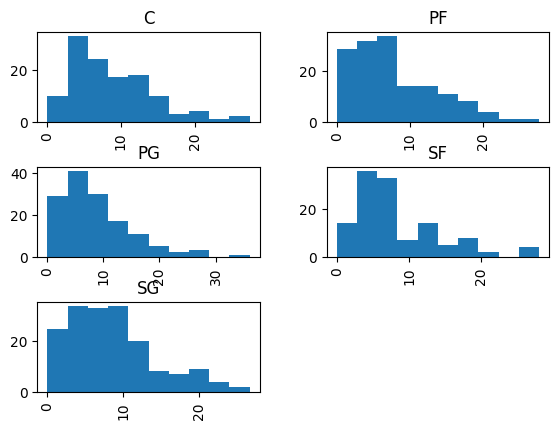

In [33]:
PTS['PTS'].hist(by=PTS['Pos'])

array([<Axes: title={'center': 'C'}>, <Axes: title={'center': 'PF'}>,
       <Axes: title={'center': 'PG'}>, <Axes: title={'center': 'SF'}>,
       <Axes: title={'center': 'SG'}>], dtype=object)

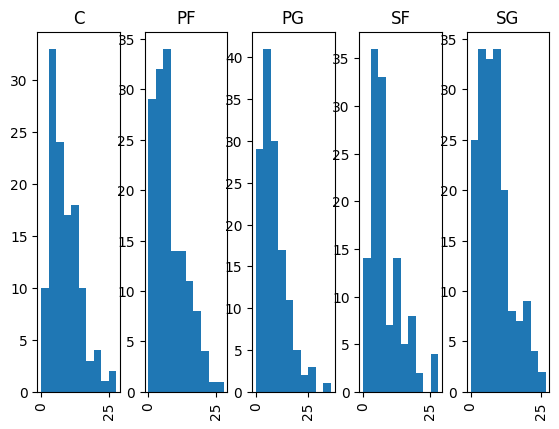

In [34]:
PTS['PTS'].hist(by=PTS['Pos'], layout=(1,5))

array([<Axes: title={'center': 'C'}>, <Axes: title={'center': 'PF'}>,
       <Axes: title={'center': 'PG'}>, <Axes: title={'center': 'SF'}>,
       <Axes: title={'center': 'SG'}>], dtype=object)

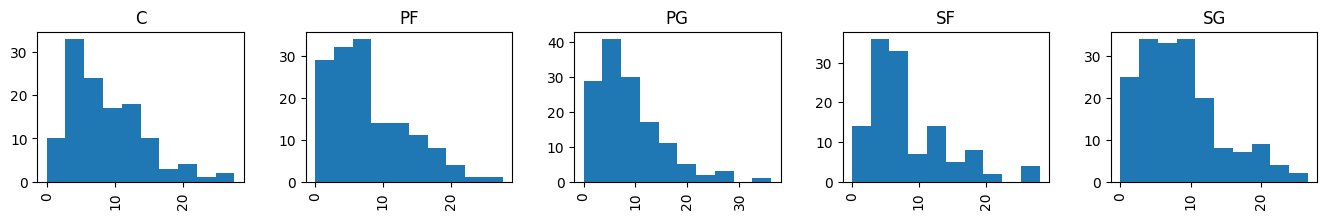

In [35]:
PTS['PTS'].hist(by=PTS['Pos'], layout=(1,5), figsize=(16,2))


``Seaborn`` data visualization

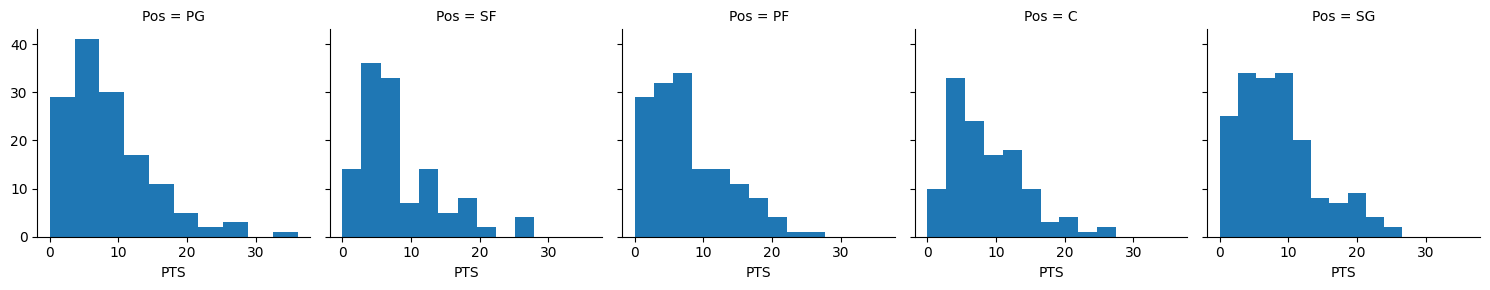

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(PTS, col="Pos")
g.map(plt.hist, "PTS")

### <span style="color:#00bfff;">3.</span> Box plots

Box plot of **points scored (PTS) grouped by Position**

``pandas`` built-in visualization

<Axes: title={'center': 'PTS'}, xlabel='Pos'>

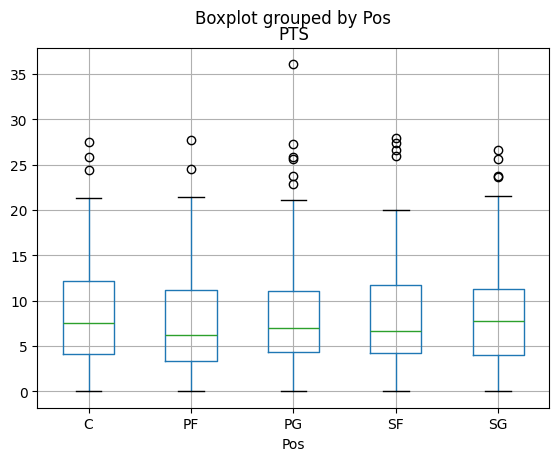

In [38]:
PTS.boxplot(column='PTS', by='Pos')

``Seaborn`` data visualization

<Axes: xlabel='Pos', ylabel='PTS'>

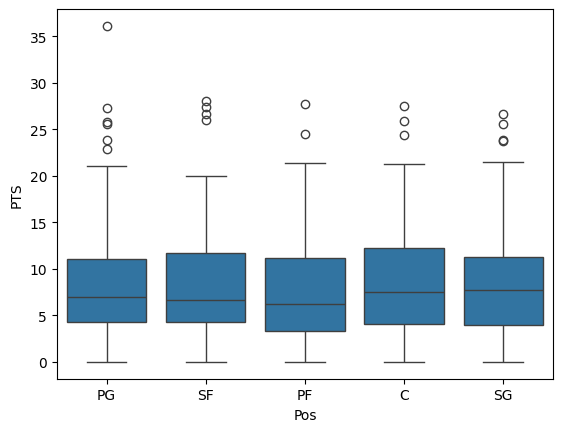

In [39]:
sns.boxplot(x = 'Pos', y = 'PTS', data = PTS) 

<Axes: xlabel='Pos', ylabel='PTS'>

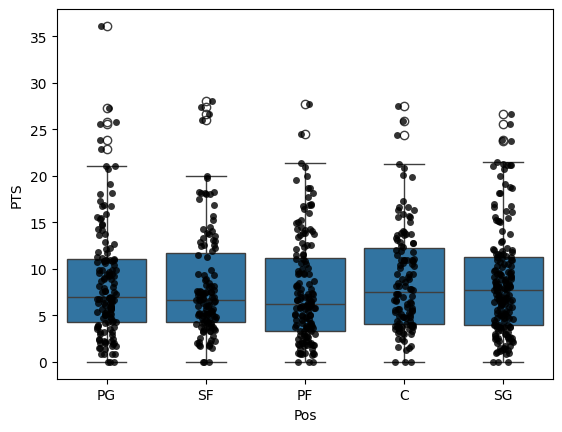

In [40]:
sns.boxplot(x = 'Pos', y = 'PTS', data = PTS) 
sns.stripplot(x = 'Pos', y = 'PTS', data = PTS,
              jitter=True, 
              marker='o',
              alpha=0.8, 
              color="black")

### <span style="color:#00bfff;">4.</span> Heat map

Compute the **correlation matrix**

In [41]:
corr = df.select_dtypes(include=['number']).corr()
corr 

,Age,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
Age,1.000000,0.079996,0.046125,0.160591,0.069211,0.085226,0.033890,0.171353,0.165518,0.074767,...,0.164248,-0.006603,0.113558,0.082868,0.147294,0.091010,0.020373,0.073895,0.123332,0.092048
G,0.079996,1.000000,0.641780,0.618993,0.542970,0.523706,0.296822,0.397646,0.378234,0.189165,...,0.417560,0.290590,0.443330,0.423467,0.414119,0.406375,0.339854,0.475034,0.478257,0.535873
GS,0.046125,0.641780,1.000000,0.764200,0.724801,0.711980,0.207984,0.497017,0.486276,0.147406,...,0.266553,0.378192,0.599511,0.568136,0.564355,0.567474,0.425170,0.650292,0.538089,0.721159
MP,0.160591,0.618993,0.764200,1.000000,0.871263,0.892577,0.249379,0.687557,0.694577,0.261490,...,0.451729,0.388144,0.696856,0.643662,0.676322,0.735643,0.439846,0.767020,0.732517,0.876070
FG,0.069211,0.542970,0.724801,0.871263,1.000000,0.973433,0.350539,0.605798,0.601831,0.217051,...,0.370360,0.465502,0.723843,0.688381,0.666474,0.636701,0.461056,0.830578,0.625604,0.990043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
STL,0.091010,0.406375,0.567474,0.735643,0.636701,0.660358,0.160470,0.476318,0.491141,0.146424,...,0.265724,0.258631,0.477312,0.438505,0.634181,1.000000,0.342891,0.629761,0.529927,0.638691
BLK,0.020373,0.339854,0.425170,0.439846,0.461056,0.363740,0.379586,0.027429,0.024166,-0.098452,...,0.150186,0.642541,0.661995,0.697728,0.149751,0.342891,1.000000,0.370123,0.563752,0.429297
TOV,0.073895,0.475034,0.650292,0.767020,0.830578,0.832936,0.213424,0.464742,0.487589,0.131881,...,0.301283,0.363787,0.656546,0.606503,0.820964,0.629761,0.370123,1.000000,0.604032,0.833912
PF,0.123332,0.478257,0.538089,0.732517,0.625604,0.593594,0.350031,0.354977,0.355415,0.092943,...,0.343748,0.552961,0.670291,0.674290,0.397911,0.529927,0.563752,0.604032,1.000000,0.614322


Make the **heat map**

<Axes: >

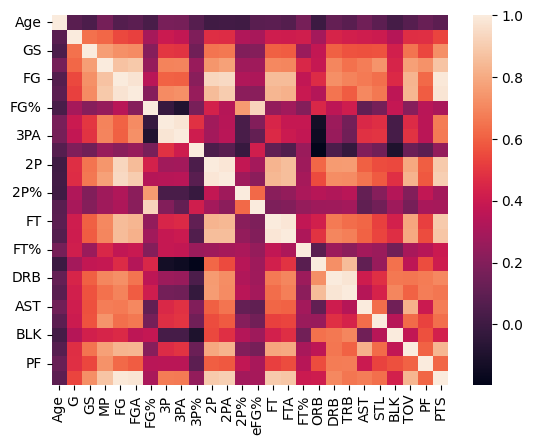

In [42]:
sns.heatmap(corr)

Adjust **figure size** of heat map

<Axes: >

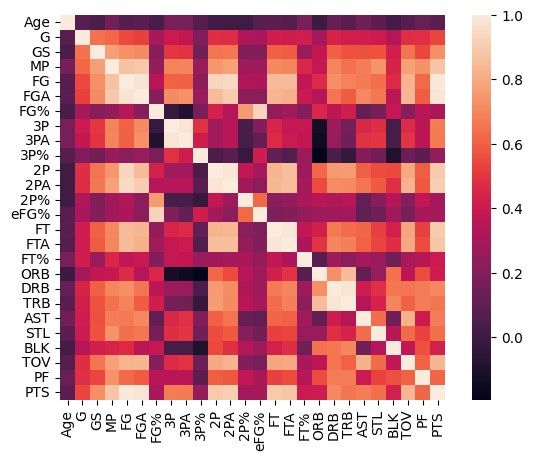

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(corr, square=True)

Mask **diagonal half** of heat map (Diagonal correlation matrix)

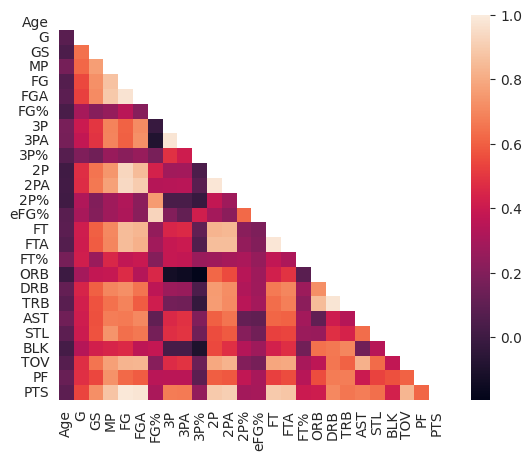

In [44]:
import numpy as np
import seaborn as sns

mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"): 
    f, ax = plt.subplots(figsize=(7, 5)) 
    ax = sns.heatmap(corr, mask=mask, vmax=1, square=True) 

### <span style="color:#00bfff;">5.</span> Scatter Plot

In [45]:
df

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,James Harden,29.0,HOU,PG,78.0,78.0,36.8,10.8,24.5,0.442,...,0.8,5.8,6.6,7.5,2.0,0.7,5.0,3.1,36.1,"MVP-2,AS,NBA1"
1,Paul George,28.0,OKC,SF,77.0,77.0,36.9,9.2,21.0,0.438,...,1.4,6.8,8.2,4.1,2.2,0.4,2.7,2.8,28.0,"MVP-3,DPOY-3,AS,NBA1,DEF1"
2,Giannis Antetokounmpo,24.0,MIL,PF,72.0,72.0,32.8,10.0,17.3,0.578,...,2.2,10.3,12.5,5.9,1.3,1.5,3.7,3.2,27.7,"MVP-1,DPOY-2,AS,NBA1,DEF1"
3,Joel Embiid,24.0,PHI,C,64.0,64.0,33.7,9.1,18.7,0.484,...,2.5,11.1,13.6,3.7,0.7,1.9,3.5,3.3,27.5,"MVP-7,DPOY-4,AS,NBA2,DEF2"
4,LeBron James,34.0,LAL,SF,55.0,55.0,35.2,10.1,19.9,0.510,...,1.0,7.4,8.5,8.3,1.3,0.6,3.6,1.7,27.4,"MVP-11,AS,NBA3"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
704,Zach Lofton,26.0,DET,SG,1.0,0.0,4.0,0.0,1.0,0.000,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0
705,Kobi Simmons,21.0,CLE,PG,1.0,0.0,2.0,0.0,0.0,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
706,Tyler Ulis,23.0,CHI,PG,1.0,0.0,1.0,0.0,0.0,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
707,Okaro White,26.0,WAS,PF,3.0,0.0,2.0,0.0,0.7,0.000,...,0.3,0.3,0.7,0.0,0.0,0.0,0.0,0.0,0.0,0


Select columns **if they have numerical** data types

In [46]:
df.select_dtypes(include=['number'])

,Age,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,29.0,78.0,78.0,36.8,10.8,24.5,0.442,4.8,13.2,0.368,...,0.879,0.8,5.8,6.6,7.5,2.0,0.7,5.0,3.1,36.1
1,28.0,77.0,77.0,36.9,9.2,21.0,0.438,3.8,9.8,0.386,...,0.839,1.4,6.8,8.2,4.1,2.2,0.4,2.7,2.8,28.0
2,24.0,72.0,72.0,32.8,10.0,17.3,0.578,0.7,2.8,0.256,...,0.729,2.2,10.3,12.5,5.9,1.3,1.5,3.7,3.2,27.7
3,24.0,64.0,64.0,33.7,9.1,18.7,0.484,1.2,4.1,0.300,...,0.804,2.5,11.1,13.6,3.7,0.7,1.9,3.5,3.3,27.5
4,34.0,55.0,55.0,35.2,10.1,19.9,0.510,2.0,5.9,0.339,...,0.665,1.0,7.4,8.5,8.3,1.3,0.6,3.6,1.7,27.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
704,26.0,1.0,0.0,4.0,0.0,1.0,0.000,0.0,1.0,0.000,...,0.000,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
705,21.0,1.0,0.0,2.0,0.0,0.0,0.000,0.0,0.0,0.000,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
706,23.0,1.0,0.0,1.0,0.0,0.0,0.000,0.0,0.0,0.000,...,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
707,26.0,3.0,0.0,2.0,0.0,0.7,0.000,0.0,0.7,0.000,...,0.000,0.3,0.3,0.7,0.0,0.0,0.0,0.0,0.0,0.0


Select the **first 5 columns** (by index number)

In [47]:
number = df.select_dtypes(include=['number'])

In [48]:
number.iloc[:,:5]

,Age,G,GS,MP,FG
0,29.0,78.0,78.0,36.8,10.8
1,28.0,77.0,77.0,36.9,9.2
2,24.0,72.0,72.0,32.8,10.0
3,24.0,64.0,64.0,33.7,9.1
4,34.0,55.0,55.0,35.2,10.1
...,...,...,...,...,...
704,26.0,1.0,0.0,4.0,0.0
705,21.0,1.0,0.0,2.0,0.0
706,23.0,1.0,0.0,1.0,0.0
707,26.0,3.0,0.0,2.0,0.0


Select 5 **specific columns** (by column names)

In [49]:
selections = ['Age', 'G', 'STL', 'BLK', 'AST', 'PTS']
df5 = df[selections]
df5

,Age,G,STL,BLK,AST,PTS
0,29.0,78.0,2.0,0.7,7.5,36.1
1,28.0,77.0,2.2,0.4,4.1,28.0
2,24.0,72.0,1.3,1.5,5.9,27.7
3,24.0,64.0,0.7,1.9,3.7,27.5
4,34.0,55.0,1.3,0.6,8.3,27.4
...,...,...,...,...,...,...
704,26.0,1.0,1.0,0.0,0.0,0.0
705,21.0,1.0,0.0,0.0,0.0,0.0
706,23.0,1.0,0.0,0.0,0.0,0.0
707,26.0,3.0,0.0,0.0,0.0,0.0


Make 5 columns **scatter plot grid**

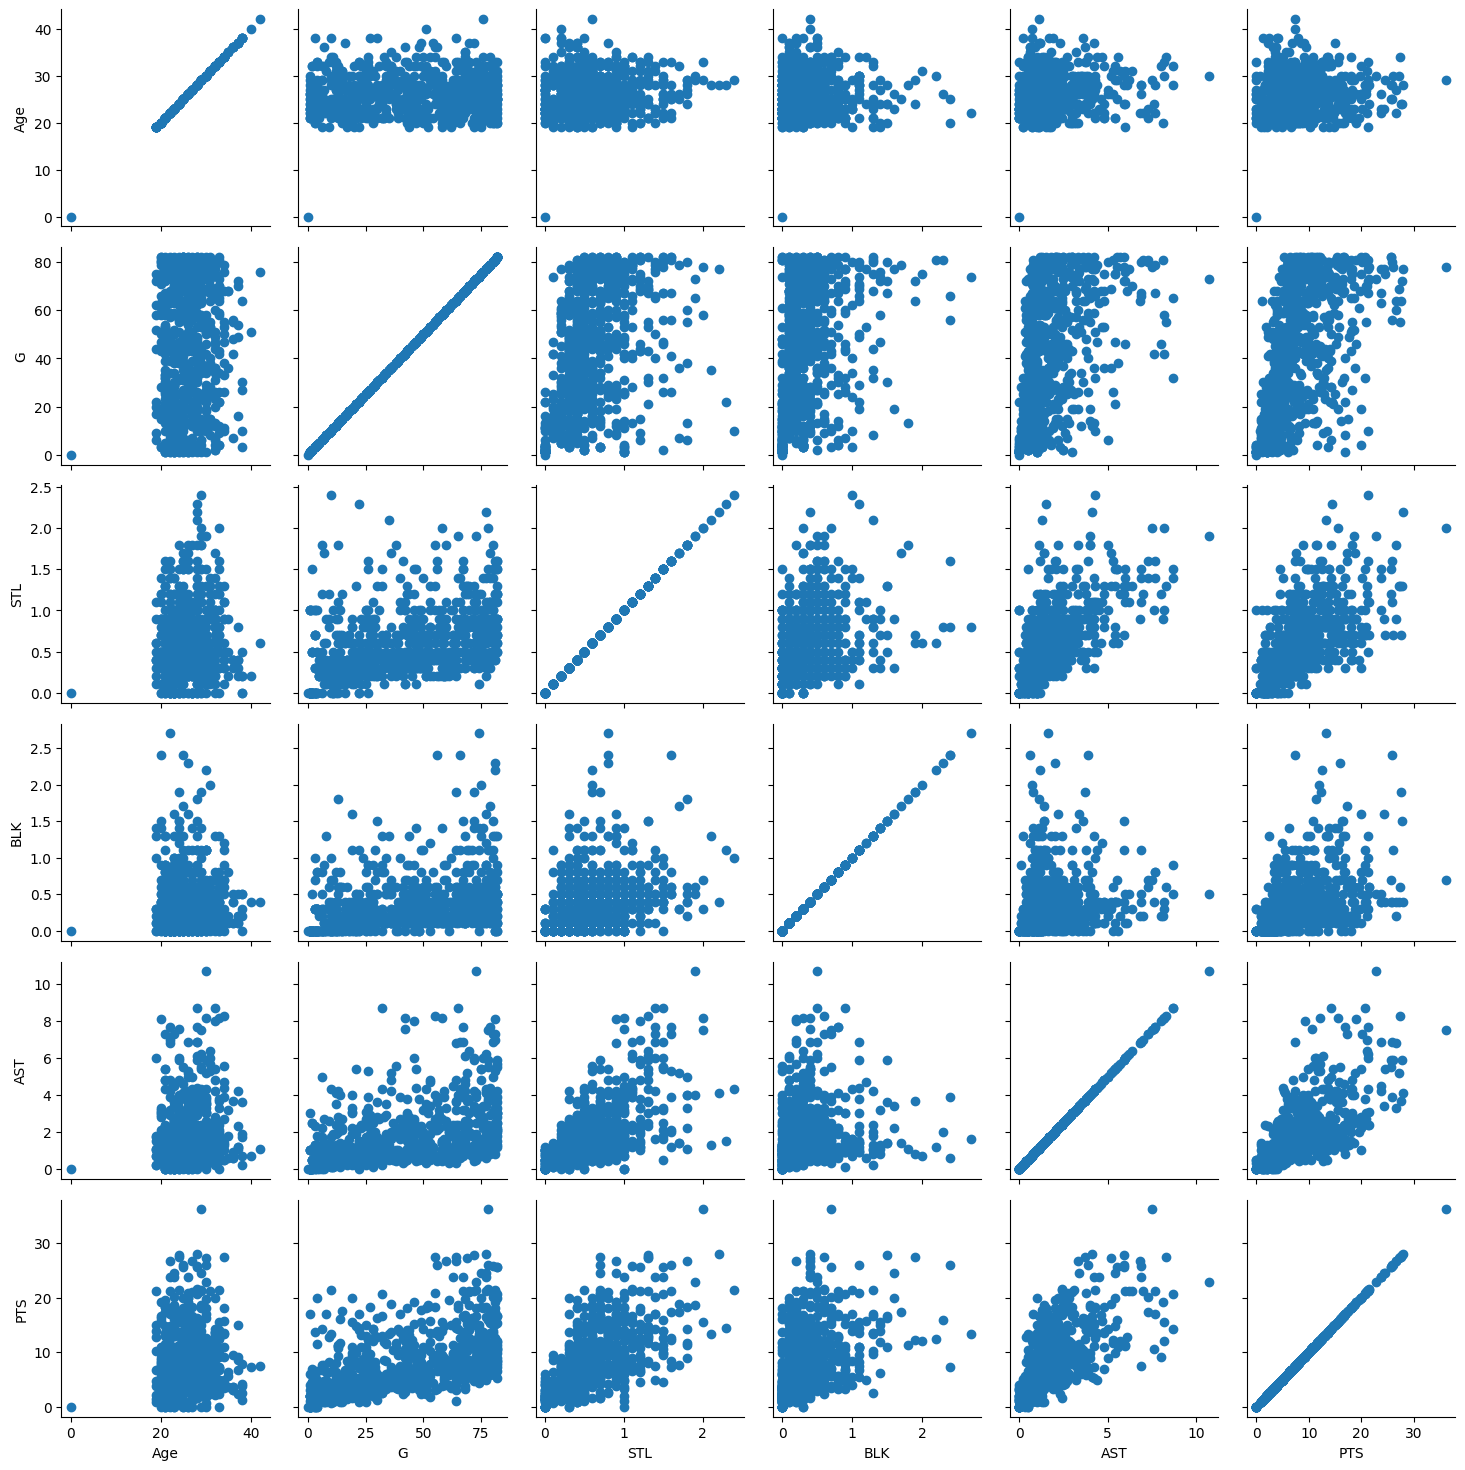

In [50]:
g = sns.PairGrid(df5)
g.map(plt.scatter)

All columns

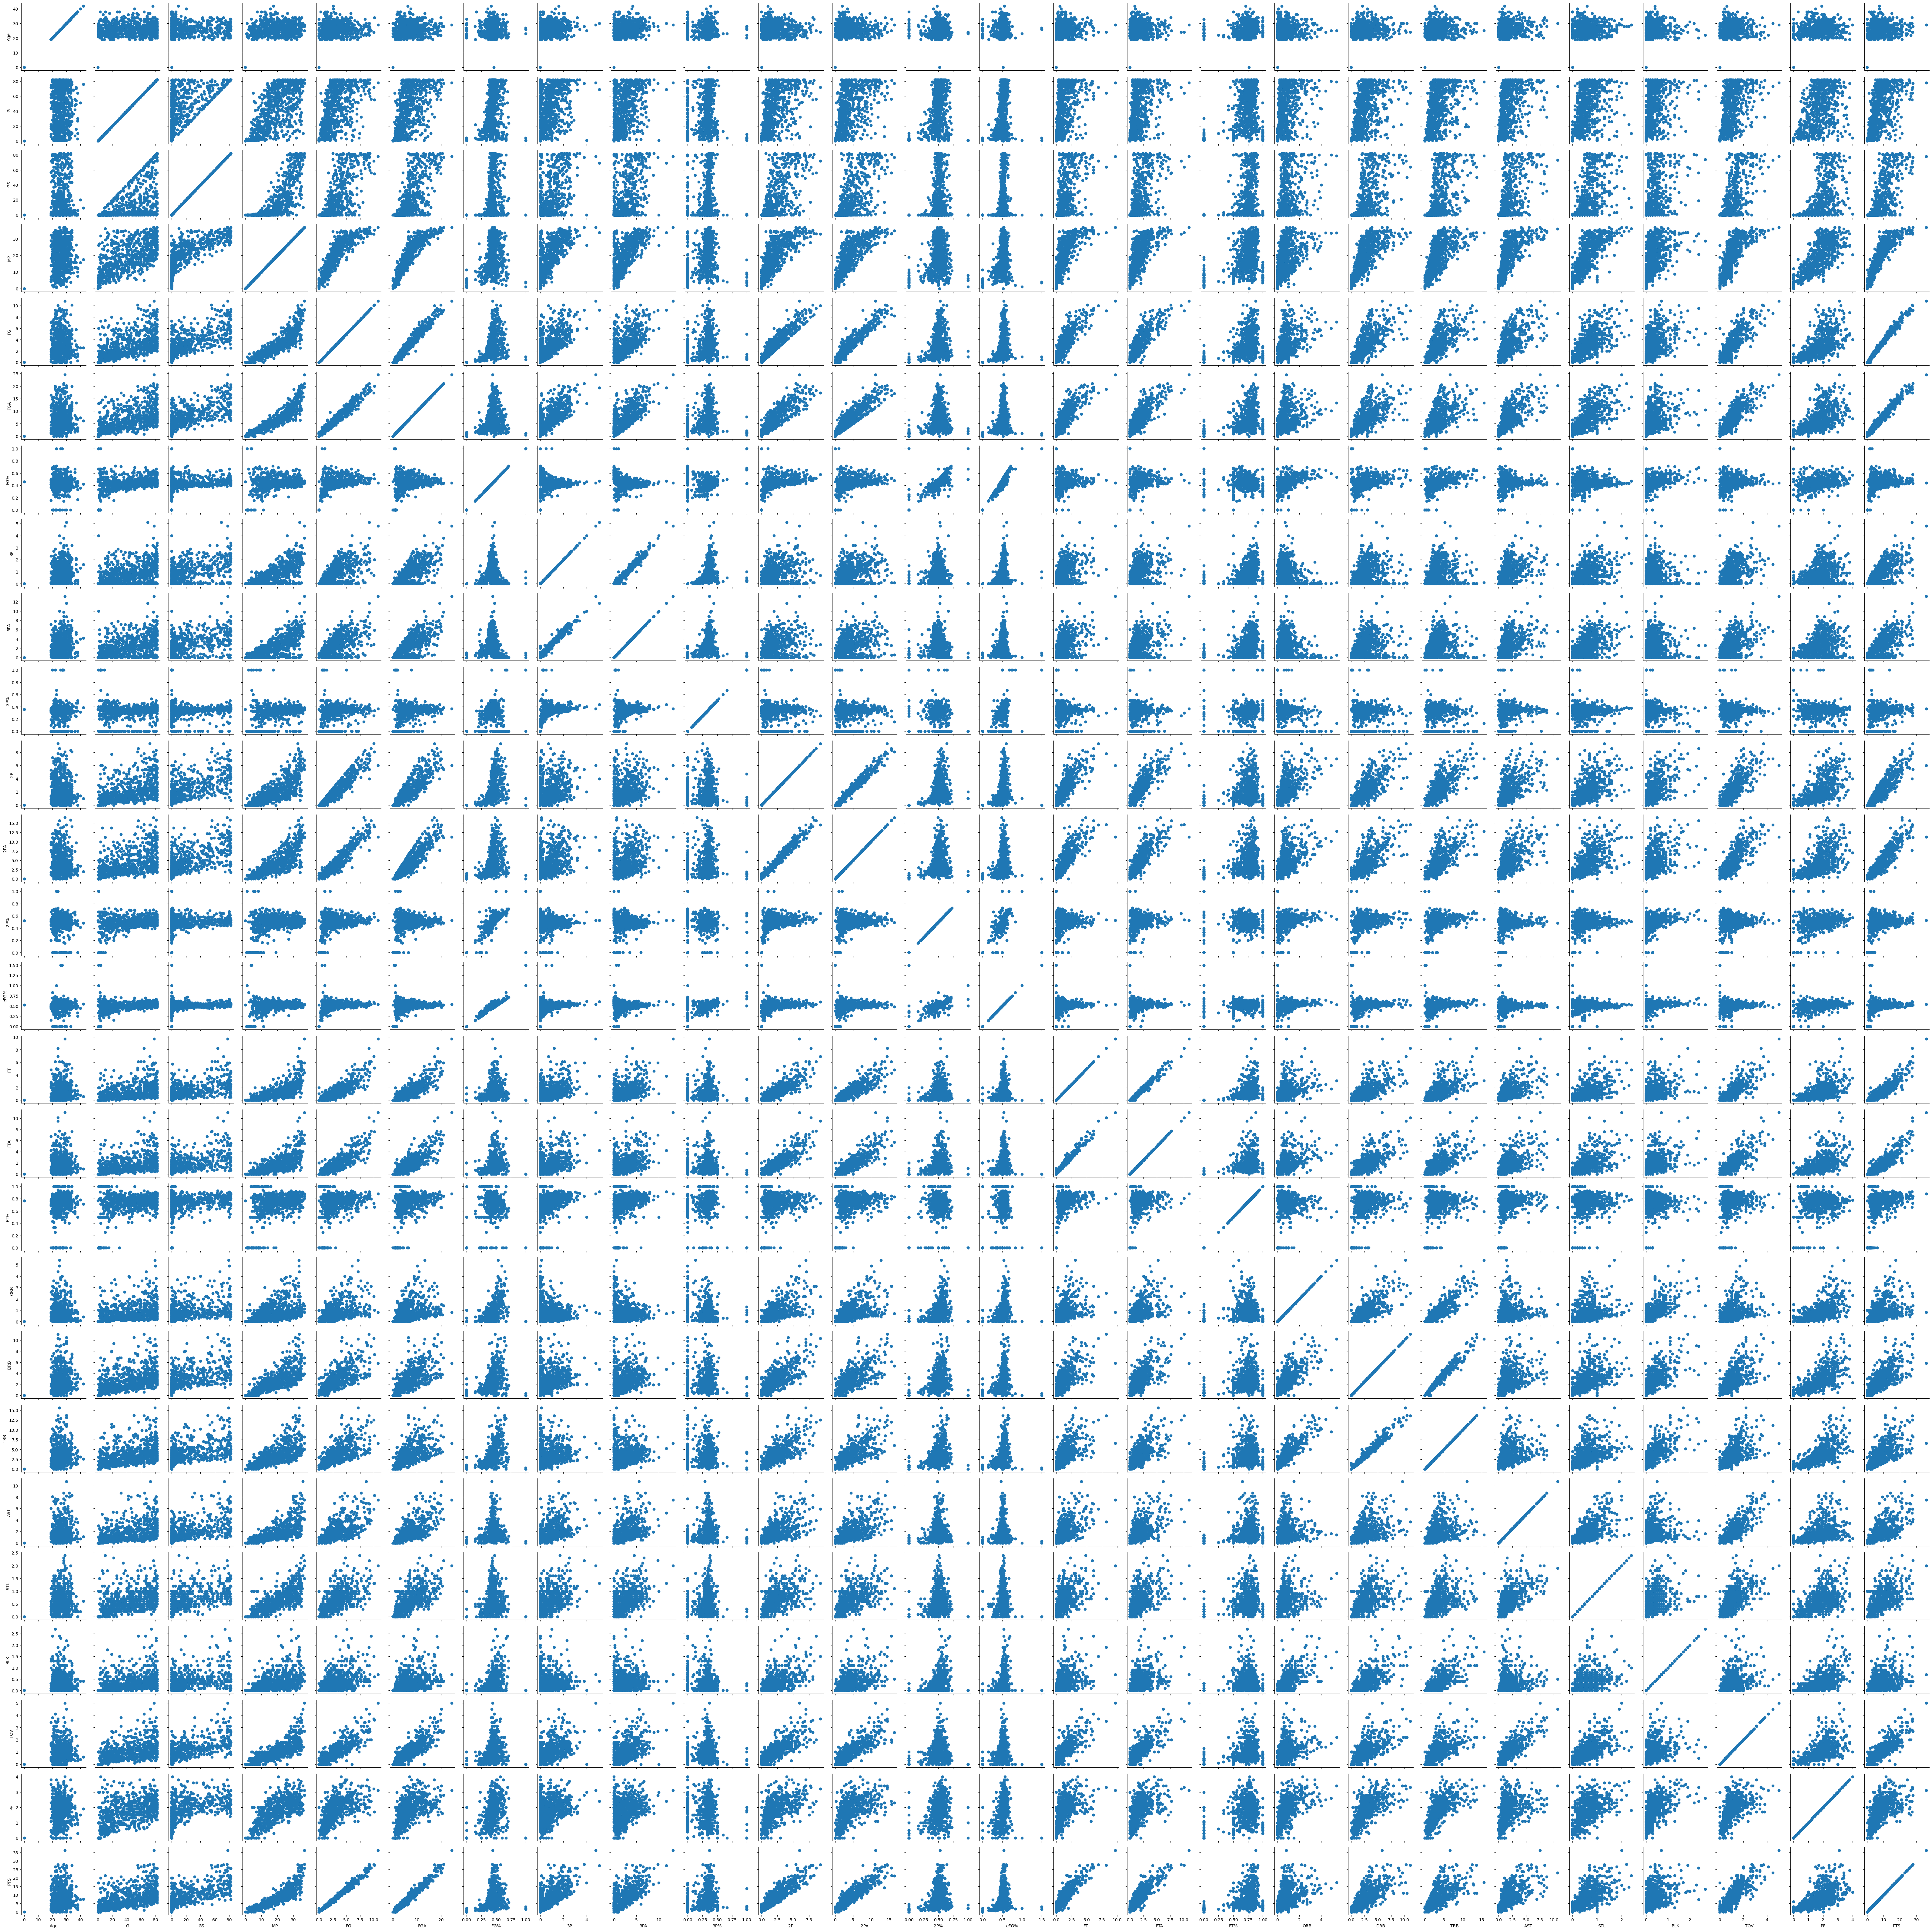

In [51]:
g = sns.PairGrid(number)
g.map(plt.scatter)